In [1]:
import pandas as pd
import pm4py
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from pm4py.visualization.dfg import visualizer as dfg_visualizer 

# Konfigurationen 
FILE_PATH = "/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/BPI Challenge 2017_1_all/BPI Challenge 2017.xes.gz"

In [2]:
# Lade das XES-Log mit Pm4Py
print(f"Lade Event Log von {FILE_PATH}...")
log_df = pm4py.read_xes(FILE_PATH)
print(log_df.shape)
print(log_df.dtypes)
print(log_df.head())

Lade Event Log von /Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/BPI Challenge 2017_1_all/BPI Challenge 2017.xes.gz...


/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/.venv/lib/python3.13/site-packages/pm4py/utils.py:991: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn("Install the optional requirement `rustxes` to import/export files faster.")
/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 31509/31509 [00:19<00:00, 1643.96it/s]


(1202267, 19)
Action                                object
org:resource                          object
concept:name                          object
EventOrigin                           object
EventID                               object
lifecycle:transition                  object
time:timestamp           datetime64[ns, UTC]
case:LoanGoal                         object
case:ApplicationType                  object
case:concept:name                     object
case:RequestedAmount                 float64
FirstWithdrawalAmount                float64
NumberOfTerms                        float64
Accepted                              object
MonthlyCost                          float64
Selected                              object
CreditScore                          float64
OfferedAmount                        float64
OfferID                               object
dtype: object
        Action org:resource            concept:name  EventOrigin  \
0      Created       User_1    A_Create Applicati

In [3]:
# Basis-Metriken

# Anzahl der Fälle
num_cases = log_df['case:concept:name'].nunique()

# Anzahl der Events
num_events = len(log_df)

# Anzahl der Aktivitäten/Event Labels
num_activities = log_df['concept:name'].nunique()

# Anzahl der Prozessvarianten
from pm4py.statistics.variants.log import get as variants_filter
variants = variants_filter.get_variants(log_df)
num_variants = len(variants)

print("--- Log-Statistiken (Quantitative Metriken) ---")
print(f"1. Anzahl der Fälle (Case Count): {num_cases:,}") # 
print(f"2. Anzahl der Events (Event Count): {num_events:,}") # 
print(f"3. Anzahl der Prozessvarianten: {num_variants:,}") # 
print(f"4. Anzahl der Aktivitäten/Event Labels: {num_activities:,}") # 

--- Log-Statistiken (Quantitative Metriken) ---
1. Anzahl der Fälle (Case Count): 31,509
2. Anzahl der Events (Event Count): 1,202,267
3. Anzahl der Prozessvarianten: 15,930
4. Anzahl der Aktivitäten/Event Labels: 26


In [4]:
# Zeitliche Metriken berechnen
from pm4py.util import constants
from pm4py.statistics.traces.generic.log import case_statistics as case_stats

# Berechnung der Falldauer
case_descriptions = case_stats.get_cases_description(
    log_df,
    parameters={
        constants.PARAMETER_CONSTANT_CASEID_KEY: 'case:concept:name',
        constants.PARAMETER_CONSTANT_TIMESTAMP_KEY: 'time:timestamp',
    },
)
case_durations = {case_id: desc["caseDuration"] for case_id, desc in case_descriptions.items()}
duration_series = pd.Series(case_durations.values())

# Prüfe auf NaN-Werte und problematische Fälle
nan_count = duration_series.isna().sum()
if nan_count > 0:
    # Finde Fälle mit NaN
    nan_cases = [case_id for case_id, dur in case_durations.items() if pd.isna(dur)]
    print(f"   Fälle mit NaN: {len(nan_cases)}")
    
    # Prüfe ob diese Fälle nur ein Event haben
    for case_id in nan_cases[:5]:  # Zeige erste 5
        case_events = log_df[log_df['case:concept:name'] == case_id]
        print(f"   - {case_id}: {len(case_events)} Events")
        if len(case_events) == 1:
            case_durations[case_id] = 0.0
        else:
            # Berechne Dauer manuell
            min_ts = case_events['time:timestamp'].min()
            max_ts = case_events['time:timestamp'].max()
            if pd.notna(min_ts) and pd.notna(max_ts):
                dur = (max_ts - min_ts).total_seconds()
                case_durations[case_id] = dur
    
    # Aktualisiere duration_series
    duration_series = pd.Series(case_durations.values())

# Entferne verbleibende NaN-Werte
duration_series_clean = duration_series.dropna()
if len(duration_series_clean) < len(duration_series):
    print(f"{len(duration_series) - len(duration_series_clean)} Fälle mit NaN wurden entfernt")
    duration_series = duration_series_clean

mean_duration_sec = duration_series.mean()
std_duration_sec = duration_series.std()

mean_duration_days = mean_duration_sec / (60*60*24)
std_duration_days = std_duration_sec / (60*60*24)
mean_duration_min = mean_duration_sec / 60
std_duration_min = std_duration_sec / 60


# Berechnung der Falllänge
case_length_series = log_df.groupby('case:concept:name').size()
mean_case_length = case_length_series.mean()
std_case_length = case_length_series.std()


print(f"1. Mittlere Falldauer: {mean_duration_days:.2f} Tage") 
print(f"Standardabweichung: {std_duration_days:.2f} Tage")

print(f"2. Mittlere Falllänge: {mean_case_length:.2f} Events")
print(f"Standardabweichung: {std_case_length:.2f} Events")

1. Mittlere Falldauer: 21.90 Tage
Standardabweichung: 13.17 Tage
2. Mittlere Falllänge: 38.16 Events
Standardabweichung: 16.72 Events


In [6]:
# Zusätzliche Metriken

def format_duration(seconds):
    days = int(seconds // (24 * 3600))
    remaining = seconds % (24 * 3600)
    hours = int(remaining // 3600)
    remaining = remaining % 3600
    minutes = int(remaining // 60)
    secs = int(remaining % 60)
    return f"{days} Tage, {hours} Stunden, {minutes} Minuten, {secs} Sekunden"

print(f"Mittlere Falldauer: {format_duration(mean_duration_sec)}")
print(f"Standardabweichung: {format_duration(std_duration_sec)}")

print(f"Median Falllänge: {case_length_series.median():.2f} Events")
print(f"Minimale Falllänge: {case_length_series.min()} Events")
print(f"Maximale Falllänge: {case_length_series.max()} Events")


Mittlere Falldauer: 21 Tage, 21 Stunden, 35 Minuten, 25 Sekunden
Standardabweichung: 13 Tage, 4 Stunden, 3 Minuten, 41 Sekunden
Median Falllänge: 35.00 Events
Minimale Falllänge: 10 Events
Maximale Falllänge: 180 Events


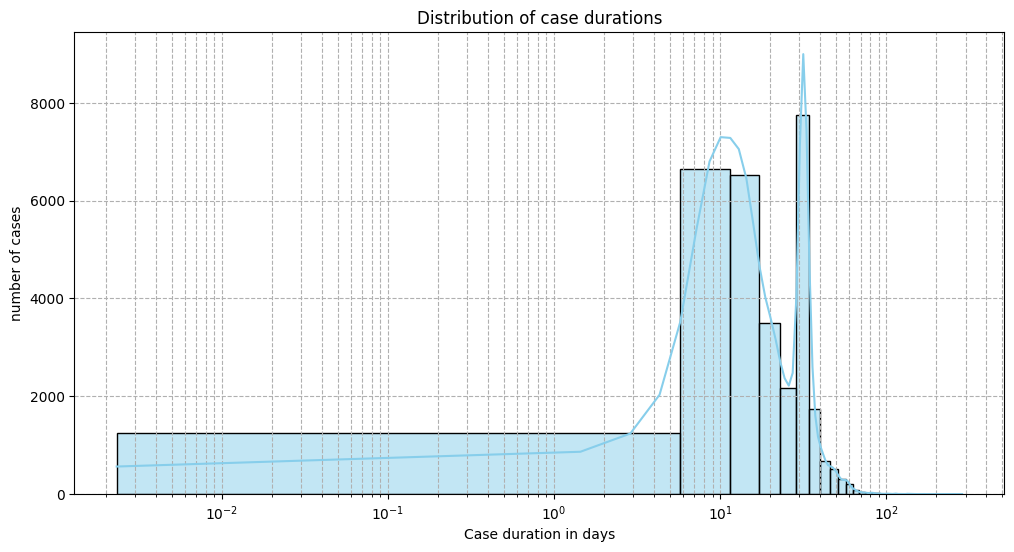

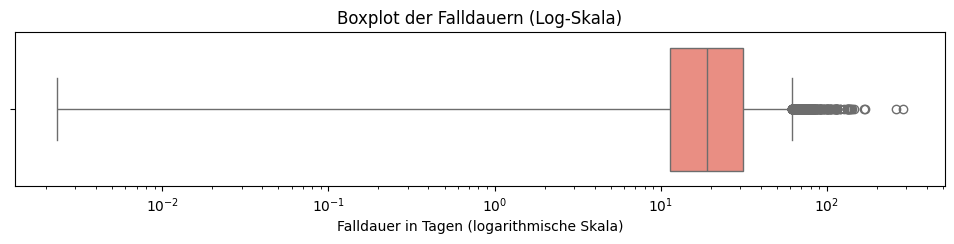

In [13]:
duration_days = duration_series / (60 * 60 * 24)

plt.figure(figsize=(12, 6))
sns.histplot(duration_days, bins=50, kde=True, log_scale=(False, False), color='skyblue')
plt.xscale('log')
plt.title('Distribution of case durations')
plt.xlabel('Case duration in days')
plt.ylabel('number of cases')
plt.grid(True, which="both", ls="--")
plt.show() 

plt.figure(figsize=(12, 2))
sns.boxplot(x=duration_days, color='salmon')
plt.xscale('log')
plt.title('Boxplot der Falldauern (Log-Skala)')
plt.xlabel('Falldauer in Tagen (logarithmische Skala)')
plt.show()

#

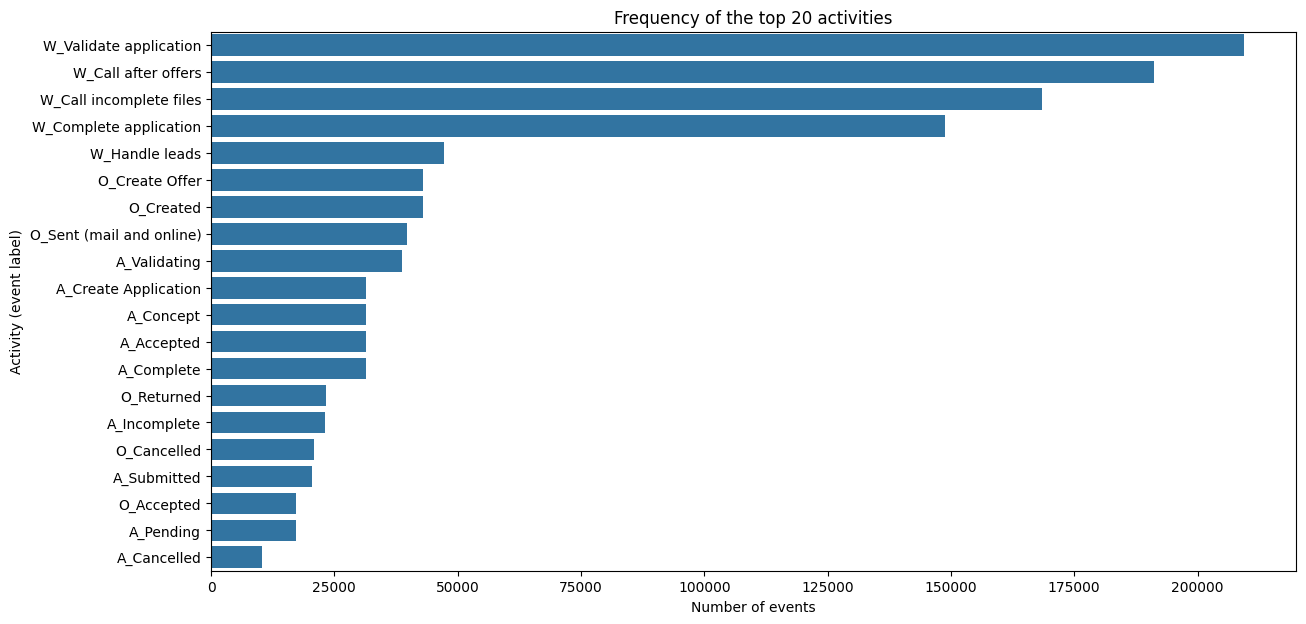

In [11]:
activity_counts = log_df['concept:name'].value_counts()

# Wähle die Top 20 Aktivitäten
top_n = 20
top_activities = activity_counts.head(top_n)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_activities.values, y=top_activities.index)
plt.title(f'Frequency of the top {top_n} activities')
plt.xlabel('Number of events')
plt.ylabel('Activity (event label)')
plt.show()

In [9]:
from pm4py.statistics.variants.log import get as variants_extractor

# Extrahiere Varianten und deren Fälle
variants_traces = variants_extractor.get_variants(log_df)

# Wandeln in DataFrame und zähle die Fälle pro Variante
variants_df = pd.DataFrame(
    [
        {"Variant_Path": variant, "Case_Count": len(traces)}
        for variant, traces in variants_traces.items()
    ]
)

# Sortiere nach der Anzahl der Fälle
variants_df = variants_df.sort_values(by='Case_Count', ascending=False).reset_index(drop=True)


total_cases = variants_df['Case_Count'].sum()
variants_df['Cumulative_Share'] = variants_df['Case_Count'].cumsum() / total_cases if total_cases else 0
print("Top 5 Prozessvarianten")
print(variants_df.head())
variants_80_percent = variants_df[variants_df['Cumulative_Share'] >= 0.80].index.min() + 1
print(f"\n{variants_80_percent} Varianten decken 80% der Fälle ab.")


Top 5 Prozessvarianten
                                        Variant_Path  Case_Count  \
0  (A_Create Application, A_Submitted, W_Handle l...        1056   
1  (A_Create Application, W_Complete application,...        1021   
2  (A_Create Application, A_Submitted, W_Handle l...         734   
3  (A_Create Application, A_Submitted, W_Handle l...         451   
4  (A_Create Application, A_Submitted, W_Handle l...         332   

   Cumulative_Share  
0          0.033514  
1          0.065918  
2          0.089213  
3          0.103526  
4          0.114063  

9629 Varianten decken 80% der Fälle ab.


In [10]:
# Holen der Falldauer

case_durations_simple = log_df.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
case_durations_simple['Duration_Sec'] = (case_durations_simple['max'] - case_durations_simple['min']).dt.total_seconds()
case_durations_simple['Length_Events'] = log_df.groupby('case:concept:name').size()

case_metrics_df = case_durations_simple[['Duration_Sec', 'Length_Events']].reset_index()


# Analyse der längsten Fälle
longest_cases = case_metrics_df.sort_values(by='Duration_Sec', ascending=False).head(3)

print("\n--- Analyse der 3 längsten Fälle (nach Dauer) ---")
for case_id in longest_cases['case:concept:name']:
    # Filtern der Events für diesen spezifischen Fall
    case_events = log_df[log_df['case:concept:name'] == case_id].sort_values(by='time:timestamp')
    path = tuple(case_events['concept:name'])
    
    print(f"\nFall ID: {case_id}")
    print(f"Dauer: {longest_cases[longest_cases['case:concept:name'] == case_id]['Duration_Sec'].iloc[0] / (60*60*24):.2f} Tage")
    # Zeige die Event-Sequenz
    print(f"Pfad (Anfang/Ende): {path[:5]} ... {path[-5:]}")


# Analyse der kürzesten Fälle
shortest_cases = case_metrics_df[case_metrics_df['Length_Events'] > 1].sort_values(by='Duration_Sec', ascending=True).head(3)

print("Analyse der 3 kürzesten Fälle")
# Formatierungsfunktion für Dauer
def format_duration(seconds):
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes} Minuten, {secs} Sekunden"

for case_id in shortest_cases['case:concept:name']:
    case_events = log_df[log_df['case:concept:name'] == case_id].sort_values(by='time:timestamp')
    path = tuple(case_events['concept:name'])
    
    duration = shortest_cases[shortest_cases['case:concept:name'] == case_id]['Duration_Sec'].iloc[0]
    
    print(f"\nFall ID: {case_id}")
    print(f"Dauer: {format_duration(duration)}")


--- Analyse der 3 längsten Fälle (nach Dauer) ---

Fall ID: Application_2011518740
Dauer: 286.07 Tage
Pfad (Anfang/Ende): ('A_Create Application', 'W_Complete application', 'W_Complete application', 'A_Concept', 'A_Accepted') ... ('W_Personal Loan collection', 'W_Personal Loan collection', 'W_Personal Loan collection', 'W_Personal Loan collection', 'W_Personal Loan collection')

Fall ID: Application_2142045957
Dauer: 259.89 Tage
Pfad (Anfang/Ende): ('A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_Complete application') ... ('W_Personal Loan collection', 'W_Personal Loan collection', 'W_Personal Loan collection', 'W_Personal Loan collection', 'W_Personal Loan collection')

Fall ID: Application_1283264254
Dauer: 169.07 Tage
Pfad (Anfang/Ende): ('A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_Handle leads') ... ('W_Call incomplete files', 'W_Call incomplete files', 'A_Cancelled', 'O_Cancelled', 'W_Call incomplete files')
Analyse